In [ ]:
%load_ext autoreload
%autoreload 2

import os

import torch
from ncpu.runner  import setup_trainer
from ncpu.config import TINY_CONJUNCTION_TRAINING_CONFIG
import mediapy as media

from matplotlib import pyplot as plt
from IPython.display import clear_output, display
from tqdm.auto import tqdm
from datetime import datetime
from ncpu.utils import print_tensor, sequence_batch_to_html_gifs

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
# TrainRunnerUI(BIG_CONJUNCTION_TRAINING_CONFIG).render()

In [9]:
trainer = setup_trainer(TINY_CONJUNCTION_TRAINING_CONFIG)

Sanity check...
  forward: torch.Size([2, 16, 32, 32]) -> torch.Size([2, 11, 16, 32, 32])
  batch: 2
  dataloader: torch.Size([24, 32, 32]) -> torch.Size([24, 32, 32])
  first_state: torch.Size([24, 16, 32, 32])
  rollout: torch.Size([24, 11, 16, 32, 32])
  loss: 0.005035400390625
Sanity check completed successfully


In [10]:
# state_dict = torch.load("notebooks/checkpoints/ncpu_127580_20251130_203719.pth")
# trainer.nca.load_state_dict(state_dict)

loss=0.005579:  13%|#3        | 26999/200000 [13:16<1:25:14, 33.83it/s]

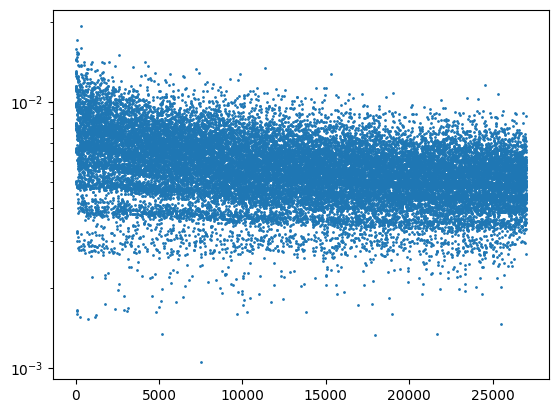

inp    : (24, 32, 32) torch.float32, min=0.00, max=1.00, mean=0.06, std=0.25
out    : (24, 32, 32) torch.float32, min=0.00, max=1.00, mean=0.08, std=0.26
nca_out: (24, 32, 32) torch.float32, min=-0.10, max=1.01, mean=0.14, std=0.28


,,,,,,,
,,,,,,,
,,,,,,,

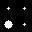
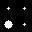
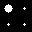
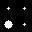
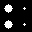
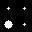
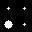
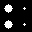
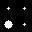
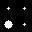
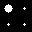
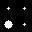
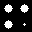
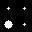
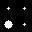
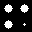
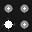
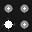
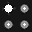
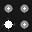
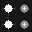
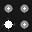
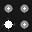
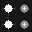

#0,#1,#2,#3,#4,#5,#6,#7

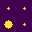
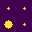
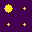
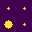
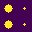
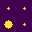
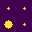
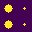

KeyboardInterrupt: 

In [11]:
pbar = tqdm(range(200_000))

for i in pbar:
    info = trainer.optim_step(steps=(30, 80))
    loss = info["loss"].item()
    pbar.set_description(f"loss={loss:.6f}")

    if i % 1000 == 0:
        with torch.no_grad():
            info = trainer.optim_step(steps=80)

        clear_output(wait=False)
        display(pbar.container)
        plt.scatter(range(len(trainer.history)), trainer.history, s=1)
        plt.yscale("log")
        plt.show()

        print_tensor("inp    ", info["inp"])
        print_tensor("out    ", info["out"])
        print_tensor("nca_out", info["nca_out"])

        to_show = 8
        inp = info["inp"][:to_show]
        out = info["out"][:to_show]
        nca_out = info["nca_out"][:to_show]
        rollout = info["rollout"][:to_show]
        io = torch.cat([inp, out, nca_out], dim=0)

        media.show_images(io.detach().cpu(), columns=to_show, width=100, height=100)
        sequence_batch_to_html_gifs(rollout, columns=to_show, fps=10)

        its = len(trainer.history)

        checkpoint_dir = "checkpoints"
        os.makedirs(checkpoint_dir, exist_ok=True)
        path = f"{checkpoint_dir}/ncpu_{its}_{datetime.now().strftime('%Y%m%d_%H%M%S')}.pth"
        torch.save(trainer.nca.state_dict(), path)

In [1]:
import panel as pn

pn.extension()

In [7]:
from functools import partial

import numpy as np
import panel as pn

from bokeh.models import ColumnDataSource
from bokeh.plotting import figure


def update(source):
    data = np.random.randint(0, 2**31, 10)
    source.data.update({"y": data})


def panel_app():
    source = ColumnDataSource({"x": np.arange(10), "y": np.arange(10)})
    p = figure()
    p.line(x="x", y="y", source=source)
    cb = pn.state.add_periodic_callback(partial(update, source), 200, timeout=5000)
    toggle = pn.widgets.Toggle(name="Toggle callback", value=True)
    toggle.link(cb, bidirectional=True, value="running")
    return pn.Column(pn.pane.Bokeh(p), toggle)


pn.panel(panel_app)

Column
    [0] Column()
    [1] Row
        [0] Column
            [0] Bokeh(figure)
            [1] Toggle(value=True)